# Regression Track — Combined Cycle Power Plant (CCPP)
### 23CSE301 Machine Learning — Capstone Project — Review 1

**Objective:** Predict the net hourly electrical energy output (`PE`) of a combined
cycle power plant from four ambient operating variables, using ten regression
algorithms trained and compared on an identical train/test split.

**Dataset:** UCI Combined Cycle Power Plant (Folds5x2_pp), 9568 rows, 4 predictors, 1 continuous target.

| Column | Meaning | Unit |
|---|---|---|
| AT | Ambient Temperature | °C |
| V  | Exhaust Vacuum | cm Hg |
| AP | Ambient Pressure | millibar |
| RH | Relative Humidity | % |
| PE | Net hourly electrical energy output (**target**) | MW |

## 0. Imports & Configuration

In [47]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 100

print("Libraries loaded. Random seed fixed at", RANDOM_STATE)

Libraries loaded. Random seed fixed at 42


## Section A — Dataset & EDA

### A1. Dataset Loading & Audit

In [48]:
df = pd.read_excel("../data/Folds5x2_pp.xlsx")

print("Shape (rows, columns):", df.shape)
print()
print("Data types:")
print(df.dtypes)
print()
print("Missing value counts:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())

Shape (rows, columns): (9568, 5)

Data types:
AT    float64
V     float64
AP    float64
RH    float64
PE    float64
dtype: object

Missing value counts:
AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

Duplicate rows: 41


In [49]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AT,9568.0,19.651231,7.452473,1.81,13.5100,20.345,25.72,37.11
V,9568.0,54.305804,12.707893,25.36,41.7400,52.080,66.54,81.56
AP,9568.0,1013.259078,5.938784,992.89,1009.1000,1012.940,1017.26,1033.30
RH,9568.0,73.308978,14.600269,25.56,63.3275,74.975,84.83,100.16
PE,9568.0,454.365009,17.066995,420.26,439.7500,451.550,468.43,495.76


**Observation:** The dataset has 9568 rows and 5 numeric columns (4 features + 1
target), with **no missing values**. All columns are `float64`. There is no categorical
target/class distribution to report since this is a regression problem; instead we
report the distribution of the continuous target `PE` below.

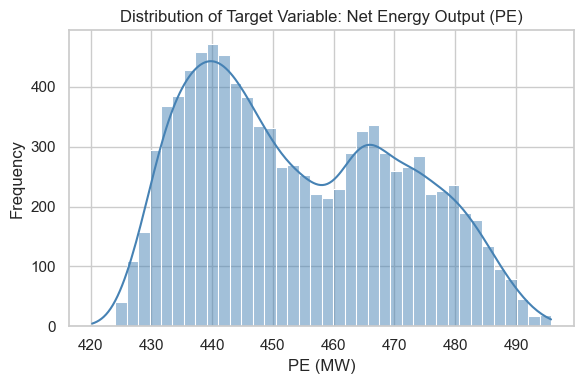

PE summary statistics:
count    9568.000000
mean      454.365009
std        17.066995
min       420.260000
25%       439.750000
50%       451.550000
75%       468.430000
max       495.760000
Name: PE, dtype: float64


In [50]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(df["PE"], kde=True, bins=40, ax=ax, color="steelblue")
ax.set_title("Distribution of Target Variable: Net Energy Output (PE)")
ax.set_xlabel("PE (MW)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

print("PE summary statistics:")
print(df["PE"].describe())

**Insight:** `PE` ranges roughly from 420 to 496 MW and is close to a symmetric,
slightly left-skewed distribution centred around 451–454 MW, with no extreme long tail —
so no target transformation (e.g. log) is needed before modelling.

### A2. EDA Visualisations

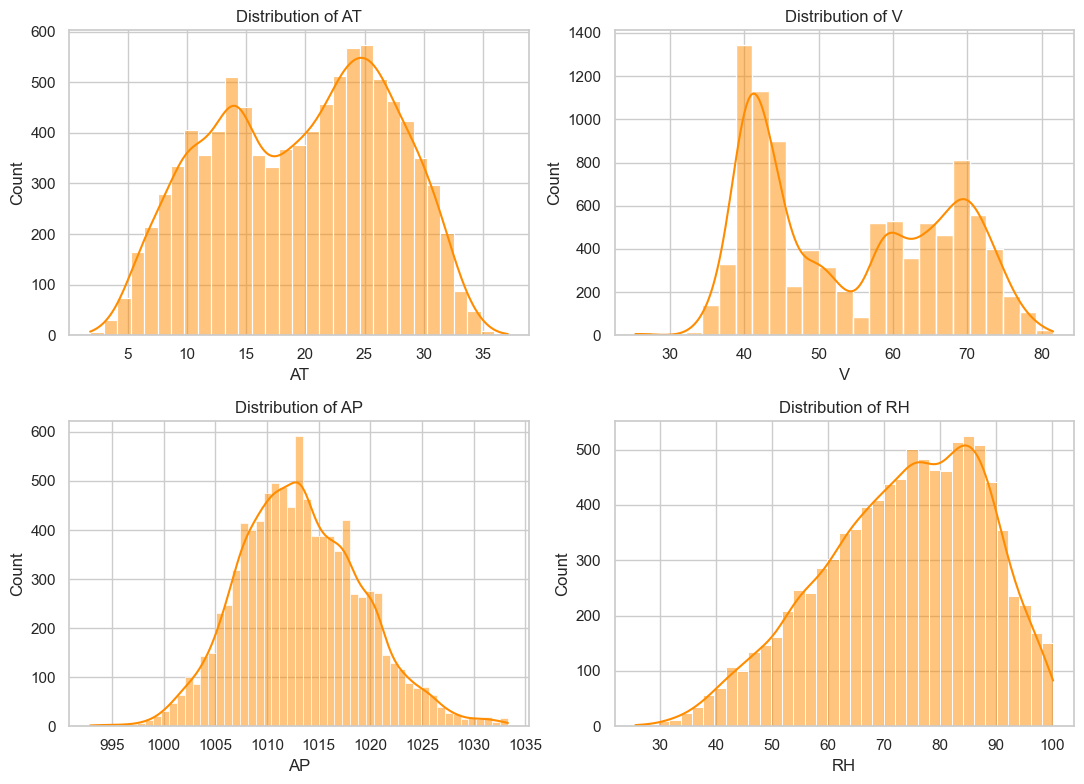

In [51]:
features = ["AT", "V", "AP", "RH"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.ravel(), features):
    sns.histplot(df[col], kde=True, ax=ax, color="darkorange")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

**Insight:** `AT` (temperature) shows a broad, slightly bimodal spread reflecting
seasonal variation across the 6 years of data collection. `V` (exhaust vacuum) is
bimodal — consistent with two distinct turbine operating regimes. `AP` is roughly
Normal. `RH` is left-skewed, with humidity concentrated in the 60–100% range.

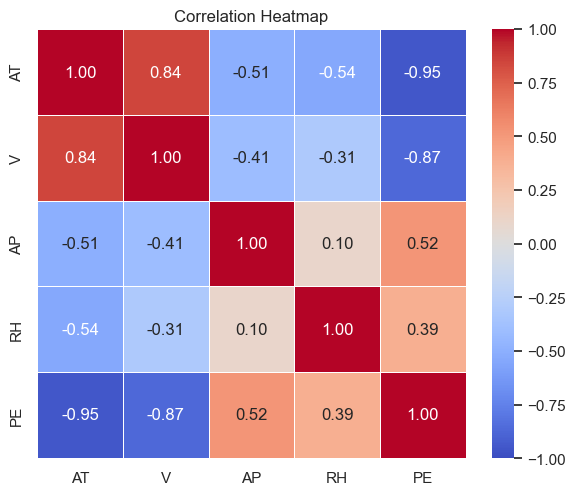

In [52]:
fig, ax = plt.subplots(figsize=(6, 5))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**Insight:** `AT` (Pearson r ≈ -0.95) and `V` (r ≈ -0.87) are strongly negatively
correlated with `PE` — higher ambient temperature and exhaust vacuum both reduce
turbine efficiency. `AP` is mildly positively correlated (r ≈ 0.52) and `RH` weakly
positively correlated (r ≈ 0.39). `AT` and `V` are themselves strongly correlated
(r ≈ 0.84), signalling possible multicollinearity that regularised linear models
(Ridge/Lasso/ElasticNet) will help control.

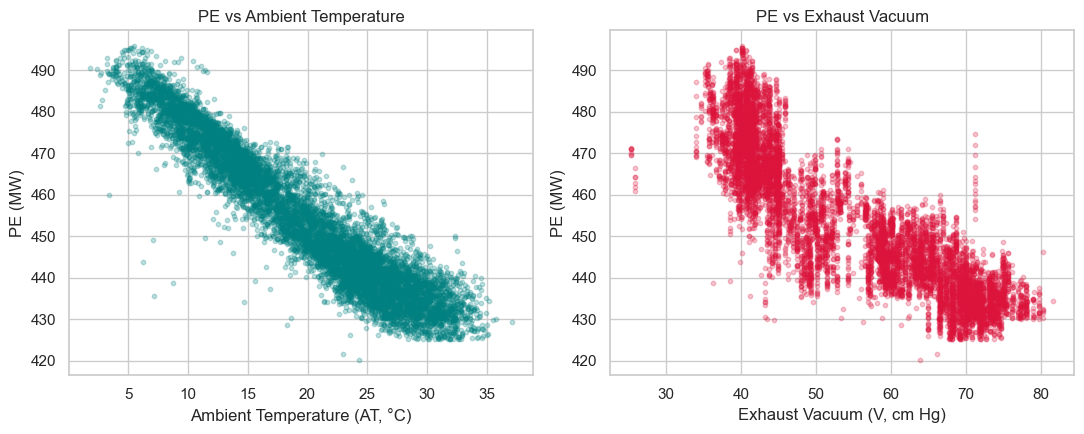

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(df["AT"], df["PE"], alpha=0.25, s=10, color="teal")
axes[0].set_xlabel("Ambient Temperature (AT, °C)")
axes[0].set_ylabel("PE (MW)")
axes[0].set_title("PE vs Ambient Temperature")

axes[1].scatter(df["V"], df["PE"], alpha=0.25, s=10, color="crimson")
axes[1].set_xlabel("Exhaust Vacuum (V, cm Hg)")
axes[1].set_ylabel("PE (MW)")
axes[1].set_title("PE vs Exhaust Vacuum")
plt.tight_layout()
plt.show()

**Insight:** Both scatter plots show a clear negative, near-linear relationship
between `PE` and `AT`/`V`, confirming these two are the dominant drivers of energy
output and justifying the inclusion of linear-family models as strong baselines.

## Section B — Preprocessing & Feature Engineering

### B1. Data Cleaning

In [54]:
print("Duplicate rows before cleaning:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)

# Outlier check via IQR rule on each numeric column
outlier_report = {}
for col in df.columns:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report[col] = n_out

print("Outlier counts (1.5*IQR rule):")
print(outlier_report)

Duplicate rows before cleaning: 41
Shape after dropping duplicates: (9527, 5)
Outlier counts (1.5*IQR rule):
{'AT': np.int64(0), 'V': np.int64(0), 'AP': np.int64(91), 'RH': np.int64(13), 'PE': np.int64(0)}


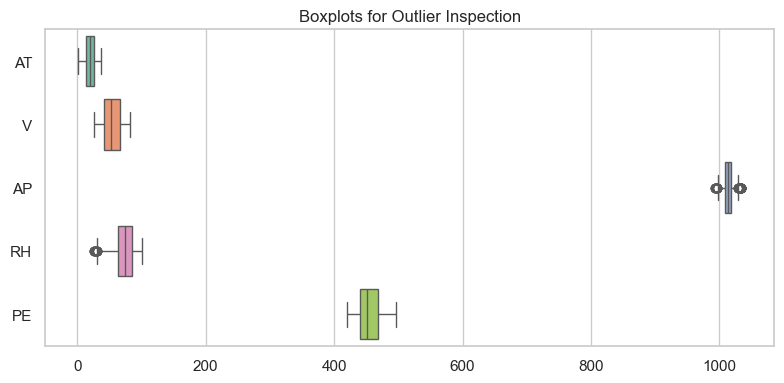

In [55]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, orient="h", ax=ax, palette="Set2")
ax.set_title("Boxplots for Outlier Inspection")
plt.tight_layout()
plt.show()

**Strategy:** A small number of `AP` and `RH` points fall outside the 1.5×IQR
whiskers. These are physically plausible ambient-condition readings (not data-entry
errors), so rather than deleting rows and losing information, they are **retained**;
their influence is controlled downstream by using tree-based ensembles (robust to
outliers) alongside scaled linear/SVR/KNN models. No missing values were present, so
no imputation was required. Exact duplicate rows found during the audit above were
dropped.

### B2. Encoding, Scaling & Splitting

In [56]:
X = df[features].copy()
y = df["PE"].copy()

# All predictors are numeric -> no categorical encoding required for this dataset.

# Stratified split: bin the continuous target into quantile bins purely to
# preserve the target's distribution shape across train and test sets.
y_bins = pd.qcut(y, q=10, labels=False, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y_bins
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

# Scaler fitted on TRAIN ONLY, then applied to both train and test (no leakage)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=features, index=X_test.index)

print("\nPost-scaling train means (~0):")
print(X_train_scaled.mean().round(3).to_dict())
print("Post-scaling train stds (~1):")
print(X_train_scaled.std().round(3).to_dict())

Train shape: (7621, 4)  Test shape: (1906, 4)

Post-scaling train means (~0):
{'AT': 0.0, 'V': -0.0, 'AP': 0.0, 'RH': 0.0}
Post-scaling train stds (~1):
{'AT': 1.0, 'V': 1.0, 'AP': 1.0, 'RH': 1.0}


**Note on scaling:** Distance/gradient-sensitive models (SVR, KNN) use the
*scaled* features. Tree-based models (Decision Tree, Random Forest, Gradient
Boosting) are scale-invariant, so they are trained on the *unscaled* split for
interpretability of feature importances in original units; this does not affect
their metrics.

### B3. Feature Engineering

In [ ]:
def add_engineered_features(X_):
    X_ = X_.copy()
    # Engineered feature 1: Temperature-Humidity Index — captures the combined
    # thermodynamic load on the gas turbine's air intake, since heat and moisture
    # jointly affect air density and therefore combustion efficiency.
    X_["Temp_Humidity_Index"] = X_["AT"] * X_["RH"] / 100.0
    # Engineered feature 2: AT-V interaction — AT and V are the two most
    # correlated-with-target features and are themselves correlated (r~0.84);
    # an explicit interaction term lets linear models capture their joint effect
    # without needing full polynomial expansion.
    X_["AT_V_interaction"] = X_["AT"] * X_["V"]
    return X_

X_train_fe = add_engineered_features(X_train)
X_test_fe = add_engineered_features(X_test)

engineered_features = features + ["Temp_Humidity_Index", "AT_V_interaction"]

scaler_fe = StandardScaler()
X_train_fe_scaled = pd.DataFrame(scaler_fe.fit_transform(X_train_fe), columns=engineered_features, index=X_train_fe.index)
X_test_fe_scaled = pd.DataFrame(scaler_fe.transform(X_test_fe), columns=engineered_features, index=X_test_fe.index)

print("Correlation of engineered features with target (train set):")
print(pd.concat([X_train_fe, y_train], axis=1).corr()["PE"][["Temp_Humidity_Index", "AT_V_interaction"]])